Apertura del file in corso...


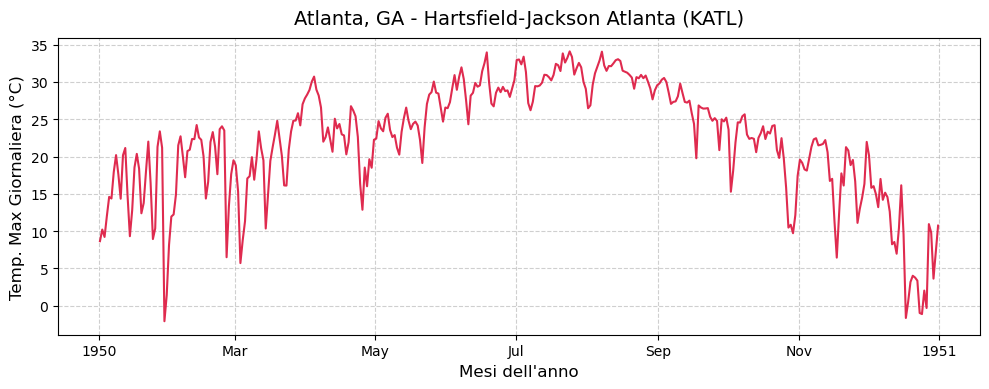

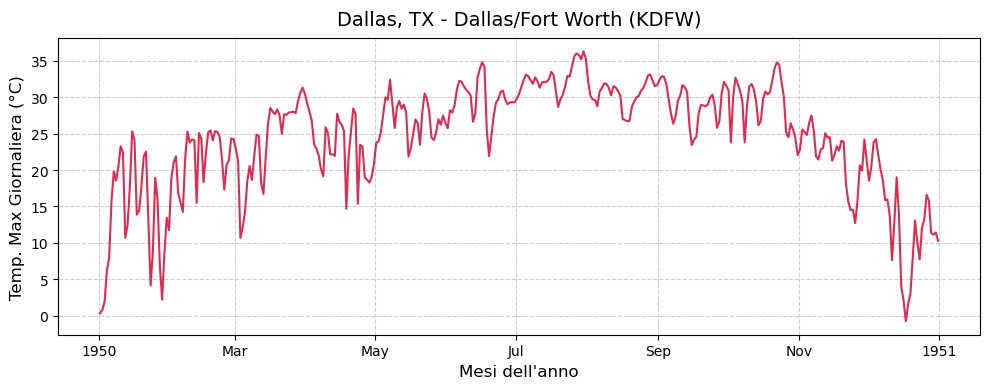

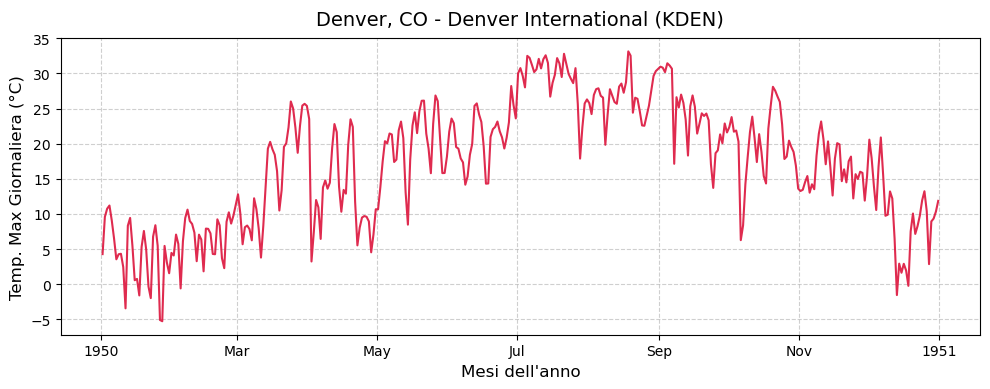

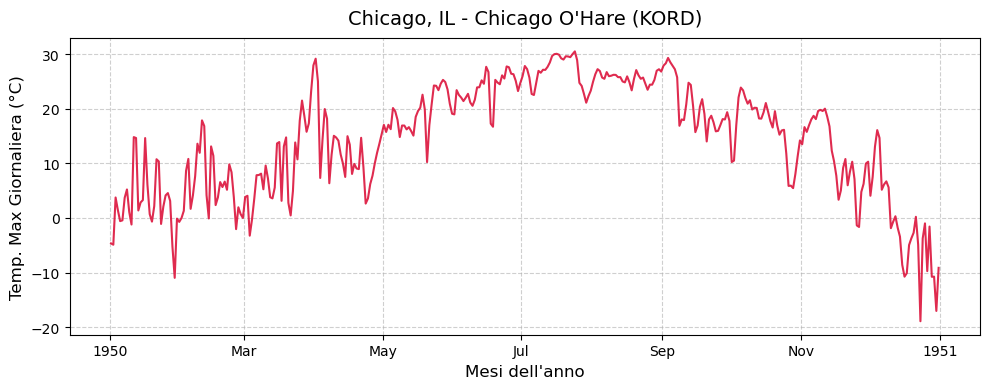

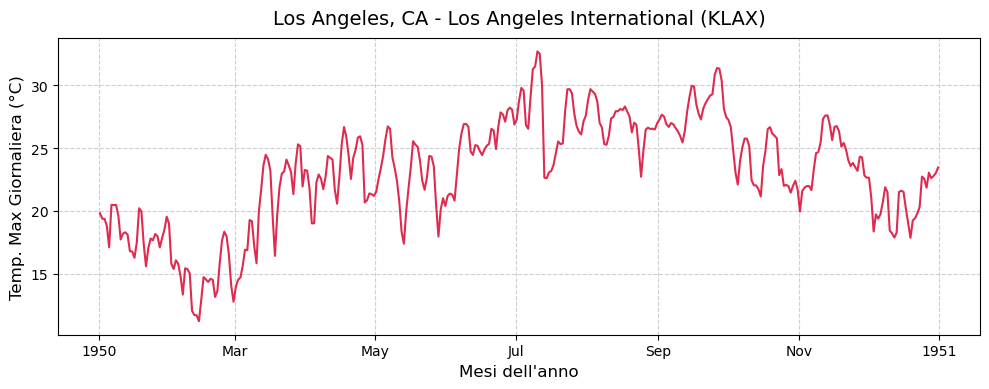

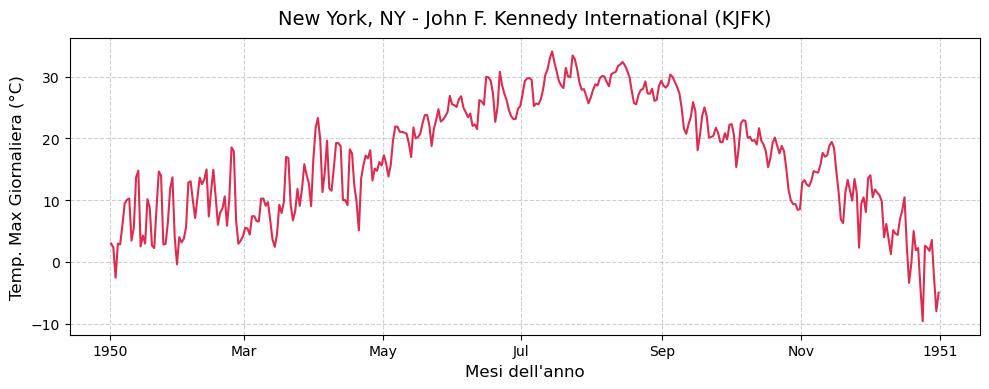

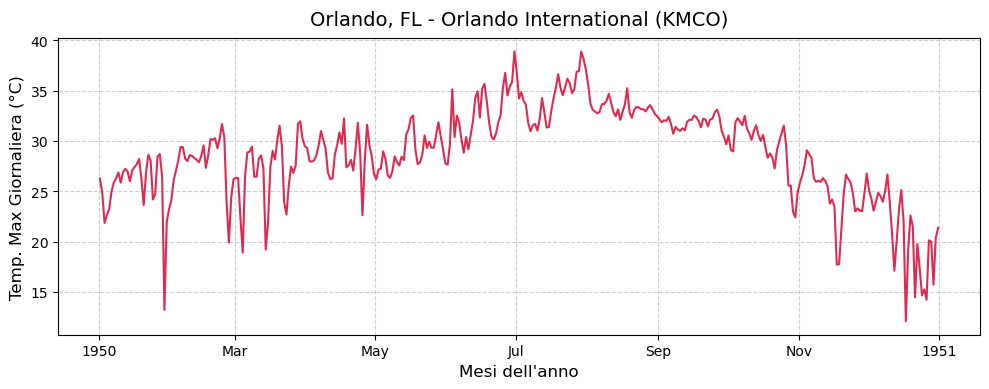

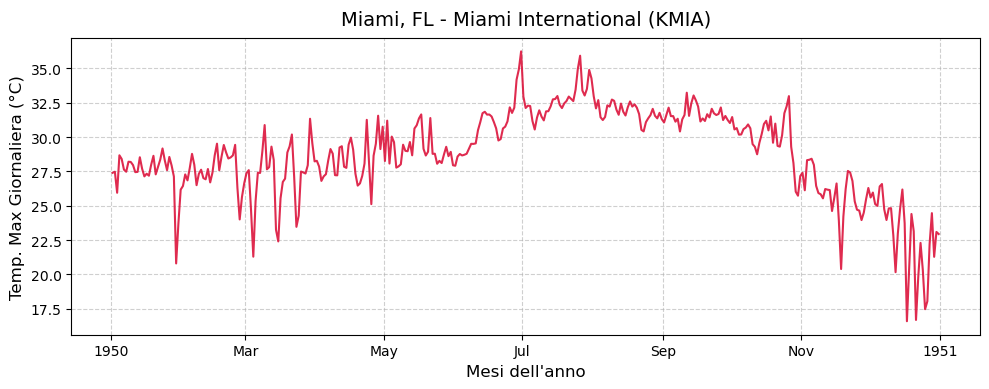

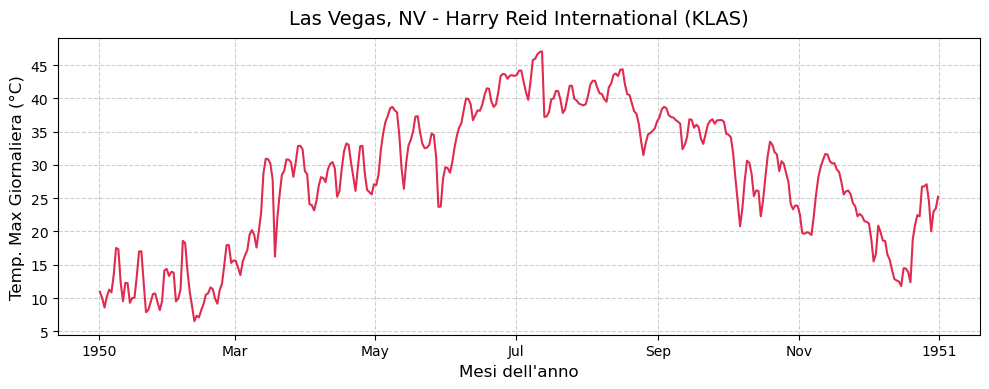

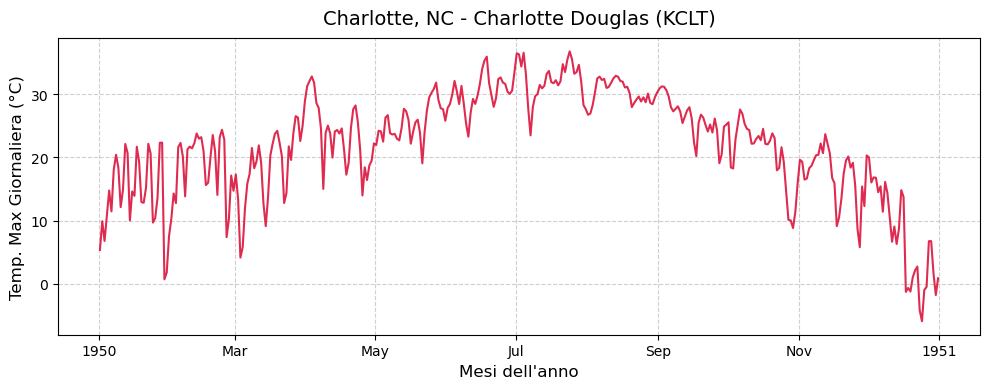

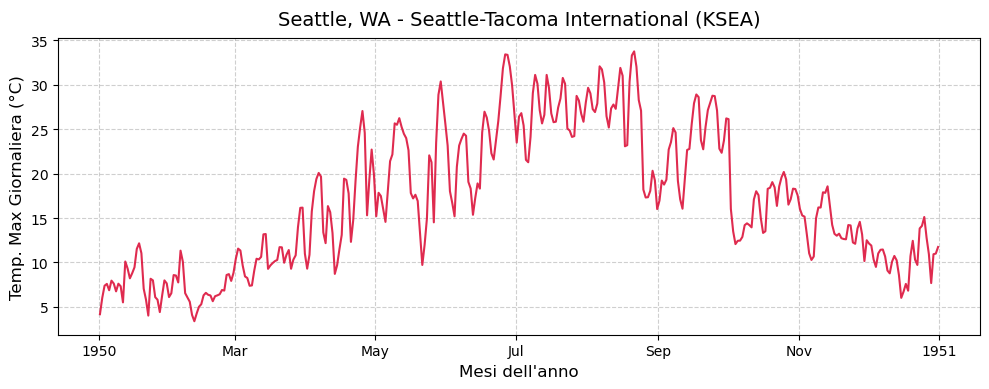

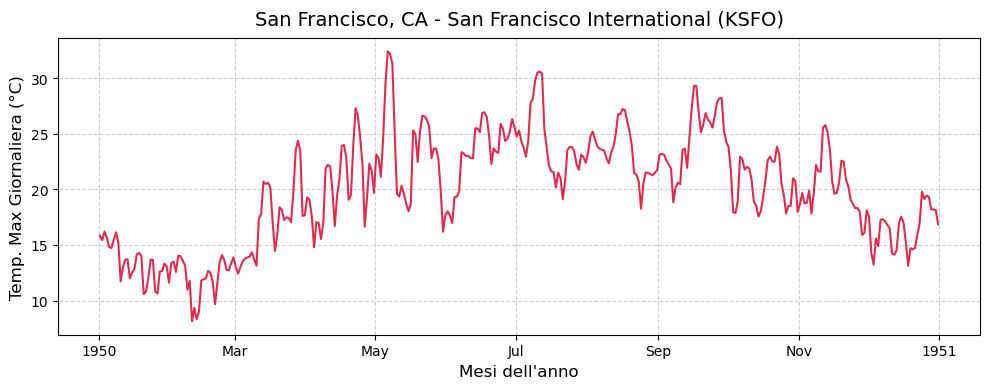

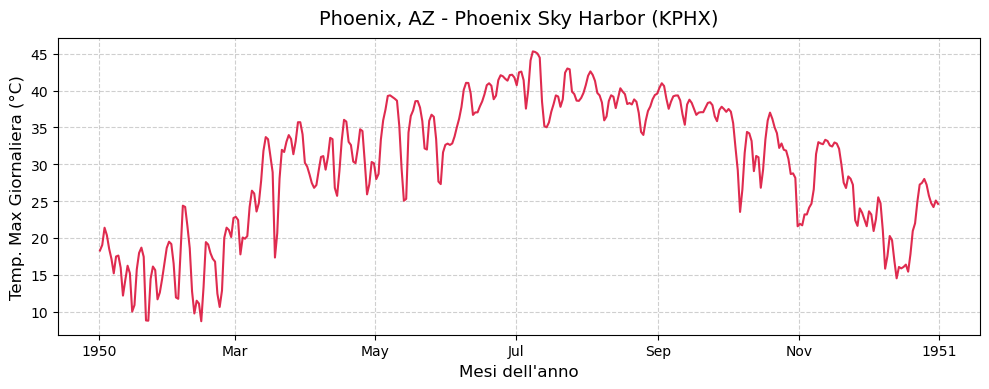

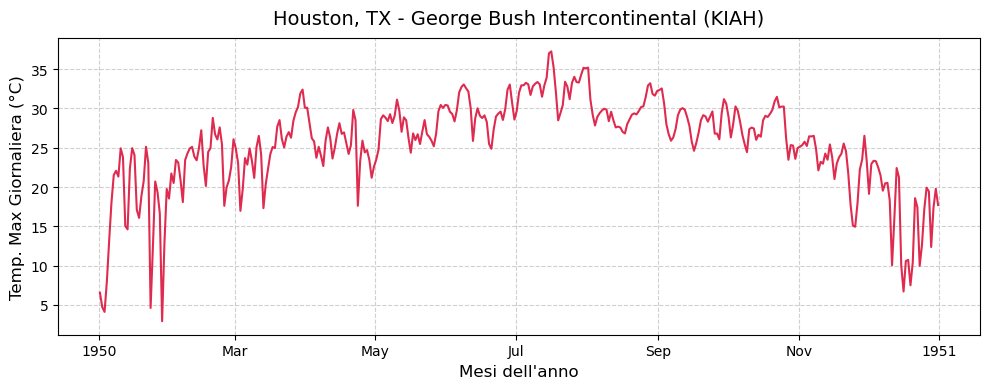

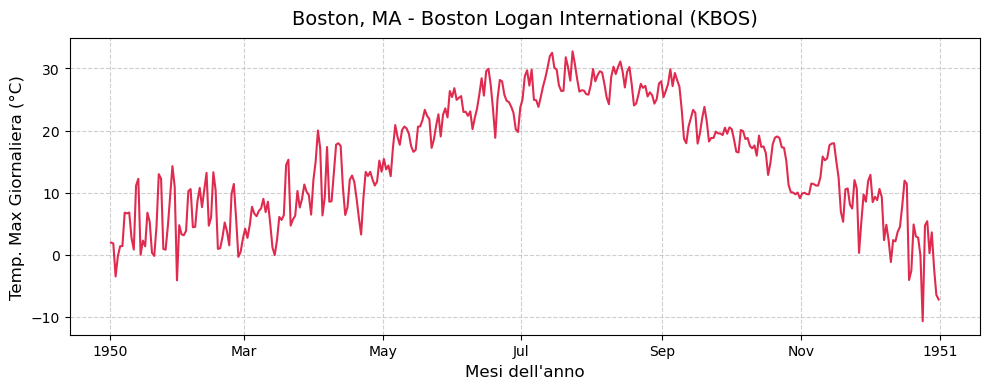

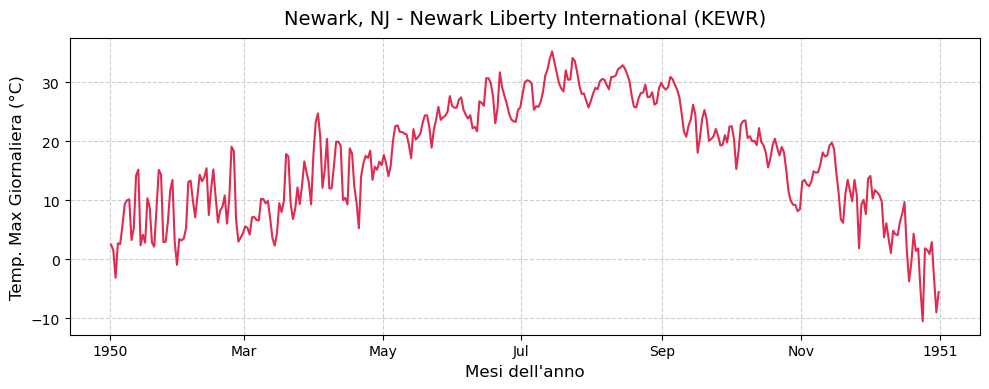

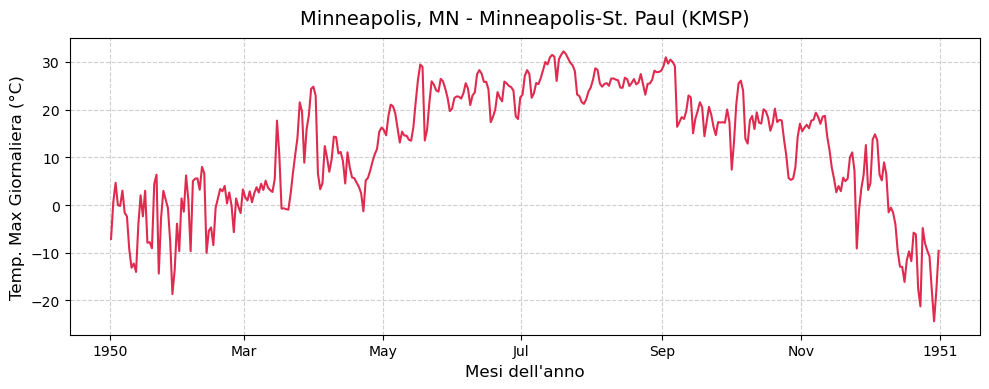

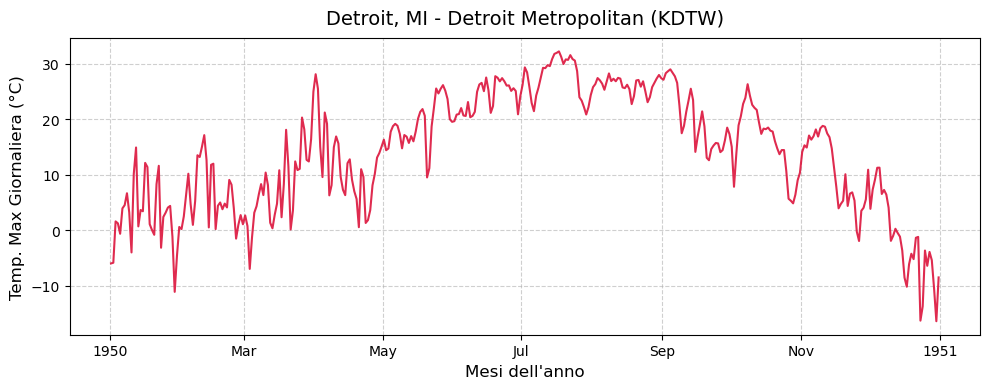

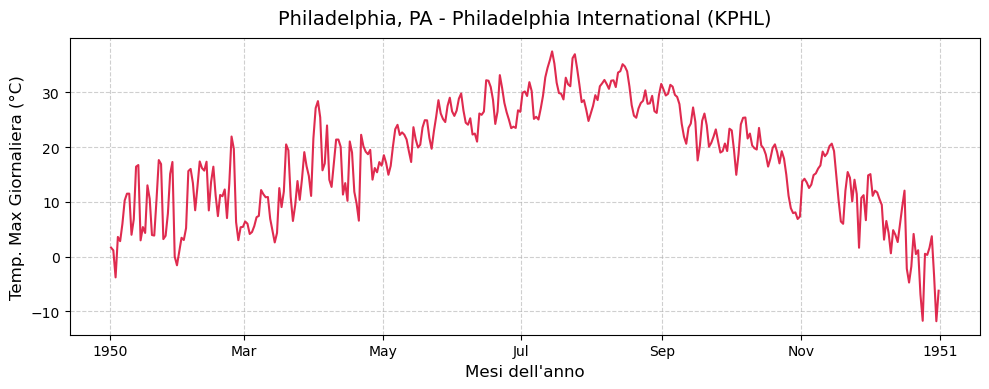

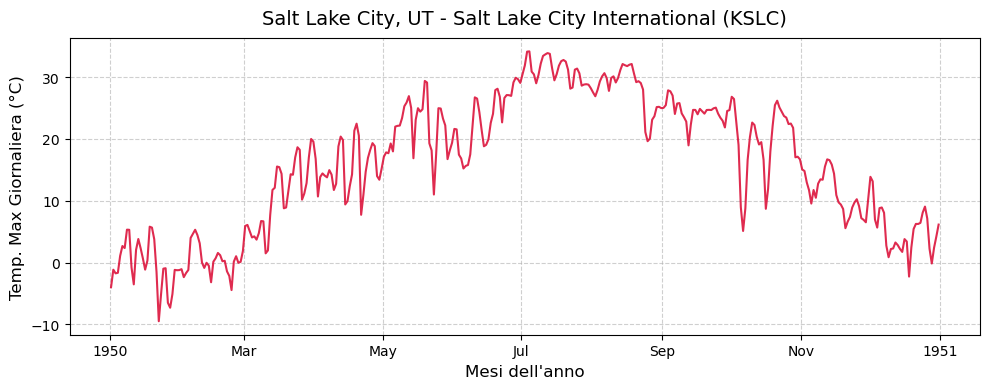

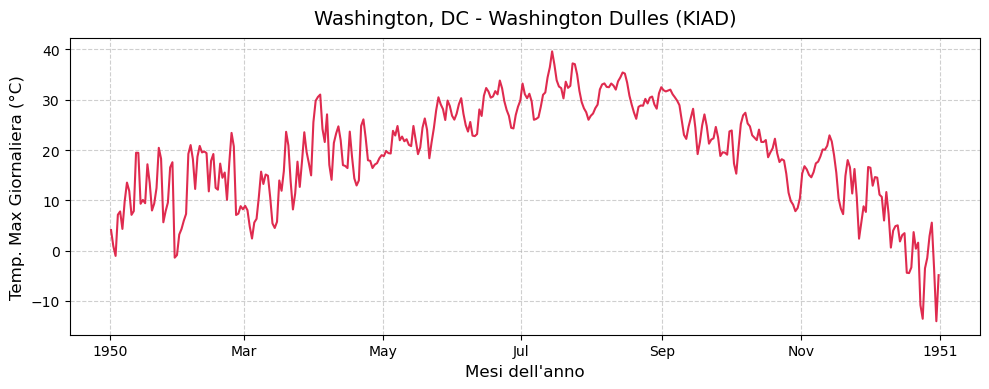

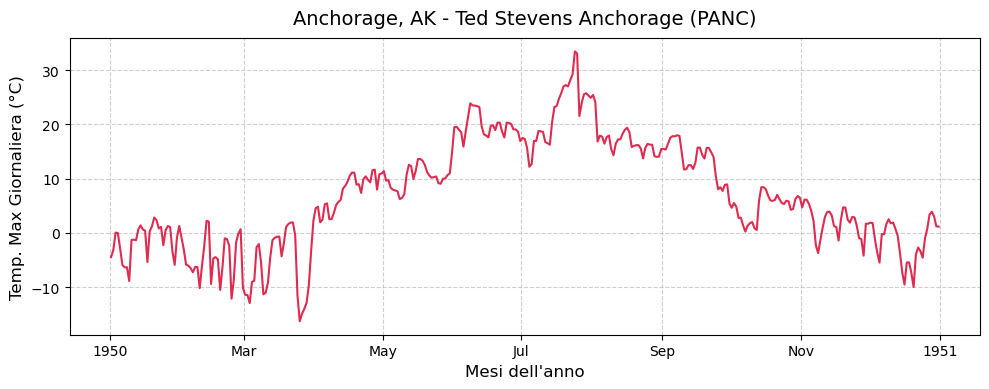

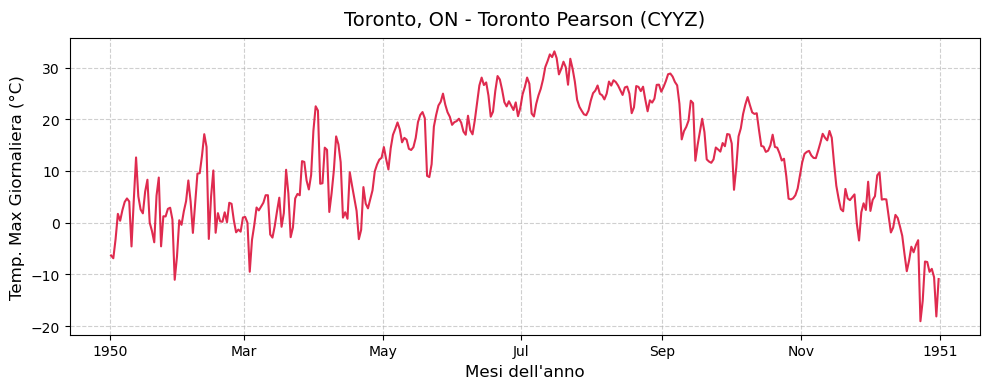

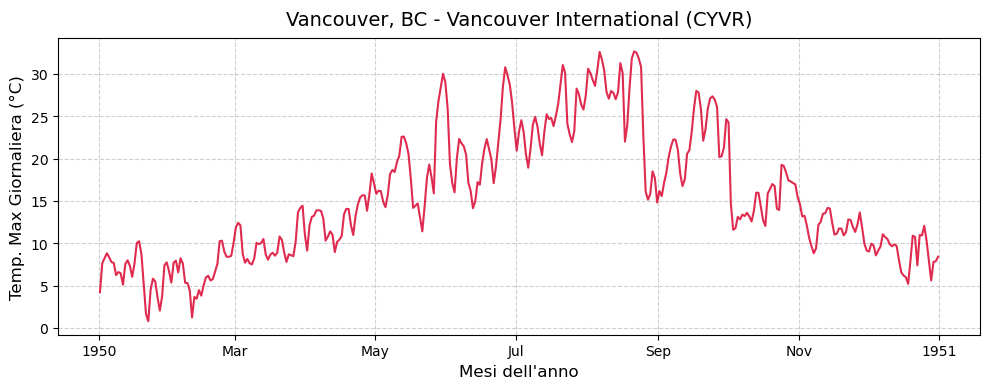

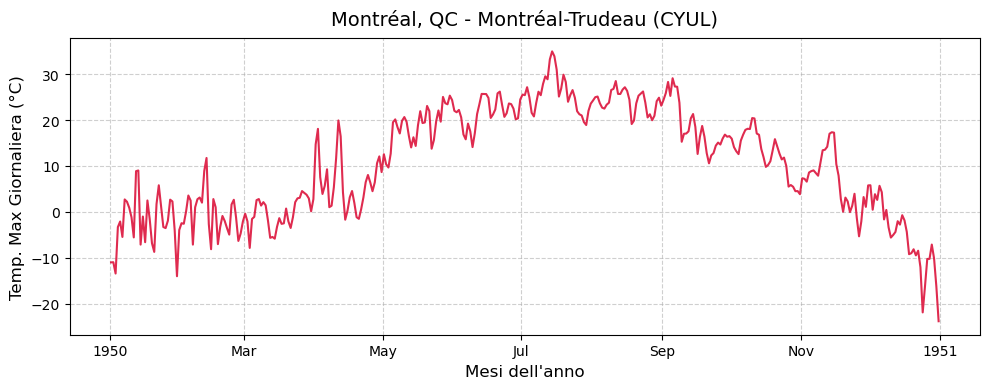

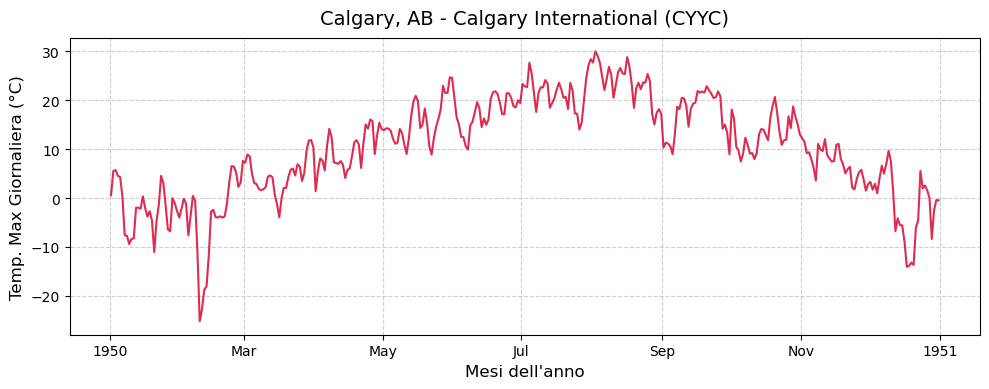

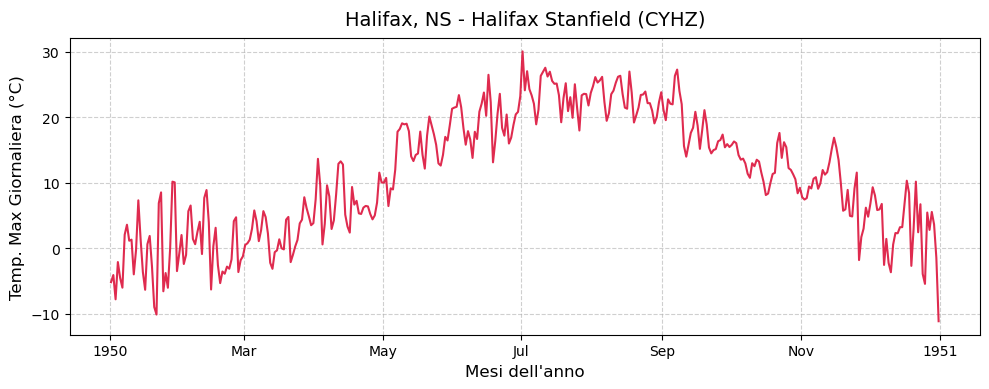

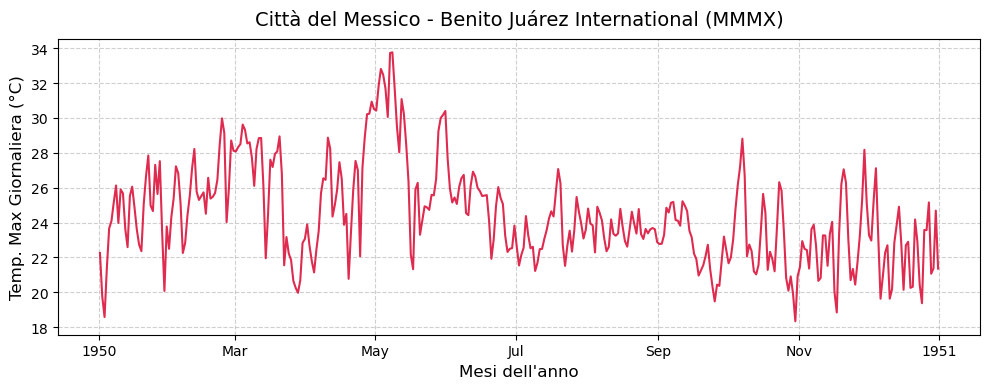

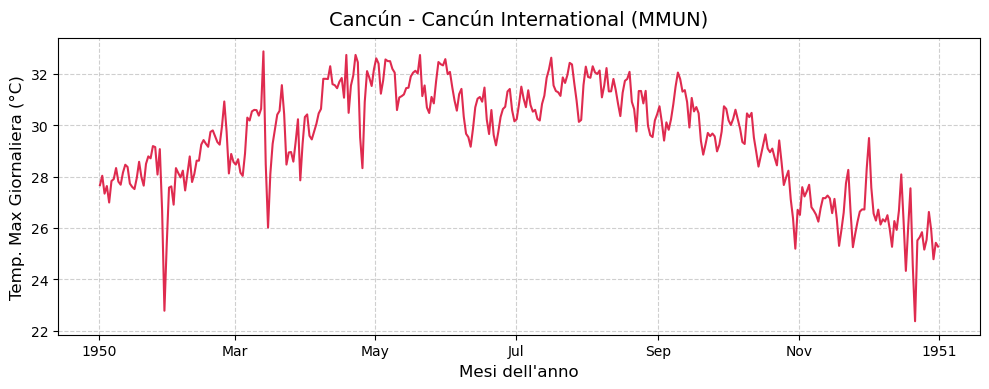

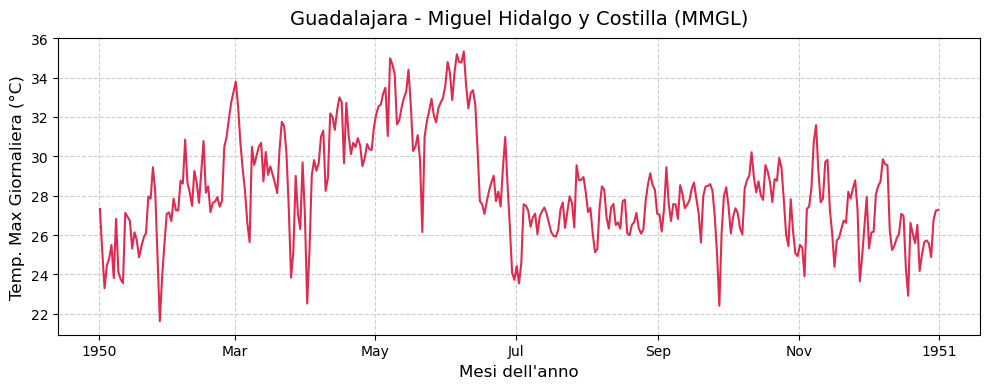

In [1]:
import xarray as xr
import matplotlib.pyplot as plt

# ==============================================================================
# 1. IMPOSTAZIONI DEL FILE
# ==============================================================================
file_storico = 'tasmax_day_ACCESS-ESM1-5_historical_r1i1p1f1_gn_1950.nc'

# ==============================================================================
# 2. DIZIONARIO DEI 30 AEROPORTI NORD-AMERICANI (USA, Canada, Messico)
# ==============================================================================
airports = {
    # USA (22)
    'KATL': {'nome': 'Hartsfield-Jackson Atlanta', 'citta': 'Atlanta, GA', 'lat': 33.6407, 'lon': -84.4277},
    'KDFW': {'nome': 'Dallas/Fort Worth', 'citta': 'Dallas, TX', 'lat': 32.8998, 'lon': -97.0403},
    'KDEN': {'nome': 'Denver International', 'citta': 'Denver, CO', 'lat': 39.8561, 'lon': -104.6737},
    'KORD': {'nome': 'Chicago O\'Hare', 'citta': 'Chicago, IL', 'lat': 41.9742, 'lon': -87.9073},
    'KLAX': {'nome': 'Los Angeles International', 'citta': 'Los Angeles, CA', 'lat': 33.9416, 'lon': -118.4085},
    'KJFK': {'nome': 'John F. Kennedy International', 'citta': 'New York, NY', 'lat': 40.6413, 'lon': -73.7781},
    'KMCO': {'nome': 'Orlando International', 'citta': 'Orlando, FL', 'lat': 28.4312, 'lon': -81.3081},
    'KMIA': {'nome': 'Miami International', 'citta': 'Miami, FL', 'lat': 25.7959, 'lon': -80.2870},
    'KLAS': {'nome': 'Harry Reid International', 'citta': 'Las Vegas, NV', 'lat': 36.0840, 'lon': -115.1537},
    'KCLT': {'nome': 'Charlotte Douglas', 'citta': 'Charlotte, NC', 'lat': 35.2140, 'lon': -80.9431},
    'KSEA': {'nome': 'Seattle-Tacoma International', 'citta': 'Seattle, WA', 'lat': 47.4502, 'lon': -122.3088},
    'KSFO': {'nome': 'San Francisco International', 'citta': 'San Francisco, CA', 'lat': 37.6213, 'lon': -122.3790},
    'KPHX': {'nome': 'Phoenix Sky Harbor', 'citta': 'Phoenix, AZ', 'lat': 33.4352, 'lon': -112.0101},
    'KIAH': {'nome': 'George Bush Intercontinental', 'citta': 'Houston, TX', 'lat': 29.9902, 'lon': -95.3368},
    'KBOS': {'nome': 'Boston Logan International', 'citta': 'Boston, MA', 'lat': 42.3656, 'lon': -71.0096},
    'KEWR': {'nome': 'Newark Liberty International', 'citta': 'Newark, NJ', 'lat': 40.6895, 'lon': -74.1745},
    'KMSP': {'nome': 'Minneapolis-St. Paul', 'citta': 'Minneapolis, MN', 'lat': 44.8848, 'lon': -93.2223},
    'KDTW': {'nome': 'Detroit Metropolitan', 'citta': 'Detroit, MI', 'lat': 42.2121, 'lon': -83.3488},
    'KPHL': {'nome': 'Philadelphia International', 'citta': 'Philadelphia, PA', 'lat': 39.8729, 'lon': -75.2437},
    'KSLC': {'nome': 'Salt Lake City International', 'citta': 'Salt Lake City, UT', 'lat': 40.7899, 'lon': -111.9791},
    'KIAD': {'nome': 'Washington Dulles', 'citta': 'Washington, DC', 'lat': 38.9531, 'lon': -77.4565},
    'PANC': {'nome': 'Ted Stevens Anchorage', 'citta': 'Anchorage, AK', 'lat': 61.1759, 'lon': -149.9901},
    
    # CANADA (5)
    'CYYZ': {'nome': 'Toronto Pearson', 'citta': 'Toronto, ON', 'lat': 43.6777, 'lon': -79.6248},
    'CYVR': {'nome': 'Vancouver International', 'citta': 'Vancouver, BC', 'lat': 49.1939, 'lon': -123.1844},
    'CYUL': {'nome': 'Montréal-Trudeau', 'citta': 'Montréal, QC', 'lat': 45.4706, 'lon': -73.7408},
    'CYYC': {'nome': 'Calgary International', 'citta': 'Calgary, AB', 'lat': 51.1215, 'lon': -114.0076},
    'CYHZ': {'nome': 'Halifax Stanfield', 'citta': 'Halifax, NS', 'lat': 44.8808, 'lon': -63.5086},
    
    # MESSICO (3)
    'MMMX': {'nome': 'Benito Juárez International', 'citta': 'Città del Messico', 'lat': 19.4361, 'lon': -99.0719},
    'MMUN': {'nome': 'Cancún International', 'citta': 'Cancún', 'lat': 21.0365, 'lon': -86.8771},
    'MMGL': {'nome': 'Miguel Hidalgo y Costilla', 'citta': 'Guadalajara', 'lat': 20.5218, 'lon': -103.3112}
}

# ==============================================================================
# 3. CARICAMENTO DATI
# ==============================================================================
print("Apertura del file in corso...")
ds = xr.open_dataset(file_storico)
var_name = 'tasmax' if 'tasmax' in ds.data_vars else 't2m'

# ==============================================================================
# 4. LOOP SU TUTTI I 30 AEROPORTI E VISUALIZZAZIONE A SCHERMO
# ==============================================================================
for icao, info in airports.items():
    
    lat_aeroporto = info['lat']
    lon_aeroporto = info['lon']
    
    # Adattamento Longitudine in caso il modello usi il formato 0-360
    lon_model = lon_aeroporto
    if lon_aeroporto < 0 and ds['lon'].max() > 180:
        lon_model = 360 + lon_aeroporto

    # Estrazione dei dati (Nearest Neighbor)
    da_local = ds[var_name].sel(lat=lat_aeroporto, lon=lon_model, method='nearest')

    # Conversione in Celsius se il file usa i Kelvin
    if da_local.attrs.get('units') == 'K':
        da_local = da_local - 273.15
        da_local.attrs['units'] = '°C'

    # Creazione del grafico
    fig, ax = plt.subplots(figsize=(10, 4))
    da_local.plot(ax=ax, color='crimson', linewidth=1.5, alpha=0.9)

    plt.title(f"{info['citta']} - {info['nome']} ({icao})", fontsize=14, pad=10)
    plt.xlabel("Mesi dell'anno", fontsize=12)
    plt.ylabel("Temp. Max Giornaliera (°C)", fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()

    # Mostra il grafico senza salvarlo
    plt.show()